# Better Data Interpolation 
Working code. Goal is to write a method for interpolating observational data that is smaller than the study area with logical values

In [1]:
import geojson
import geopandas as gpd
import rasterio
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import firedrake
from firedrake import Constant, inner, jump, grad, dx, avg, dS, min_value, max_value, conditional, pi, assemble
import icepack
from matplotlib.colors import LinearSegmentedColormap
import irksome
from irksome import Dt
import cmcrameri.cm as cmc
from cmcrameri import show_cmaps
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FormatStrFormatter)
import matplotlib.colors as col
from tqdm.notebook import trange, tqdm

In [2]:
def subplots(obs1, transform, window, *args, **kwargs):
    fig, axes = plt.subplots(figsize = (10,8))
    xmin, ymin, xmax, ymax = rasterio.windows.bounds(window, transform)
    extent = (xmin, xmax, ymin, ymax)
    plot = axes.imshow(
        obs1, 
        cmap="Blues_r", 
        extent=extent
    )
    fig.colorbar(plot,                       
                      orientation = 'vertical', 
                      shrink=0.65, 
                      pad = 0.01, 
                      aspect=50)

    return fig, axes

def fix_obs(field, file):
    ny, nx = field.shape
    bound_loc = file.bounds
    
    xh = np.linspace(bound_loc.left, bound_loc.right, nx)
    yh = np.linspace(bound_loc.bottom, bound_loc.top, ny)[::-1]

    return xr.DataArray(
        field,
        dims=("y", "x"),
        coords={"x": xh, "y": yh},
    )


λ = 900.0

## Reading in relevant files
Outline, thickness, bed profile

In [3]:
home_dir = '../data/'

outline_fn = home_dir + 'emmons_outine/emmons_1896_full.geojson'

m1_h = home_dir + 'Thickness/m1-thickness_RGI60-02.14297.tif'
m2_h = home_dir + 'Thickness/m2-thickness_RGI60-02.14297.tif'
m3_h = home_dir + 'Thickness/m3-thickness_RGI60-02.14297.tif'

dave_bed = home_dir + 'surfaces/clipped_bed_dave.tif' 

In [4]:
with open(outline_fn, "r") as outline_file:
    outline = geojson.load(outline_file)

In [5]:
δ = 0.0

coords = np.array(list(geojson.utils.coords(outline)))
xmin, xmax = coords[:, 0].min() - δ, coords[:, 0].max() + δ
ymin, ymax = coords[:, 1].min() - δ, coords[:, 1].max() + δ

print(f'Outline Bbox: left={xmin}, bottom={ymin}, right={xmax}, top={ymax}')

Outline Bbox: left=594789.305348, bottom=5188812.476617, right=602562.551396, top=5195084.940482


## Thickness Data

In [6]:
# Thickness File (Farinotti)
m2_file = rasterio.open(m2_h, 'r')
h_transform = m2_file.transform
bounds = m2_file.bounds

h_window = rasterio.windows.from_bounds(
    *bounds, 
    transform=h_transform
).round_lengths().round_offsets()

m2_obs = m2_file.read(indexes=1, window = h_window, masked = True)

In [7]:
m1_file = rasterio.open(m1_h, 'r')
h1_transform = m1_file.transform
bounds1 = m1_file.bounds

h1_window = rasterio.windows.from_bounds(
    *bounds1, 
    transform=h1_transform
).round_lengths().round_offsets()

m1_obs = m1_file.read(indexes=1, window = h1_window, masked = True)

In [8]:
m3_file = rasterio.open(m3_h, 'r')
h3_transform = m3_file.transform
bounds3 = m3_file.bounds

h3_window = rasterio.windows.from_bounds(
    *bounds3, 
    transform=h3_transform
).round_lengths().round_offsets()

m3_obs = m3_file.read(indexes=1, window = h3_window, masked = True)

In [9]:
# Error calculation from inter model varience
N = 3

m_avg = m1_obs + m2_obs + m3_obs / N
m_σ = (
      ((m1_obs - m_avg) ** 2 
    + (m2_obs - m_avg) ** 2
    + (m3_obs - m_avg) ** 2) / N) ** 0.5

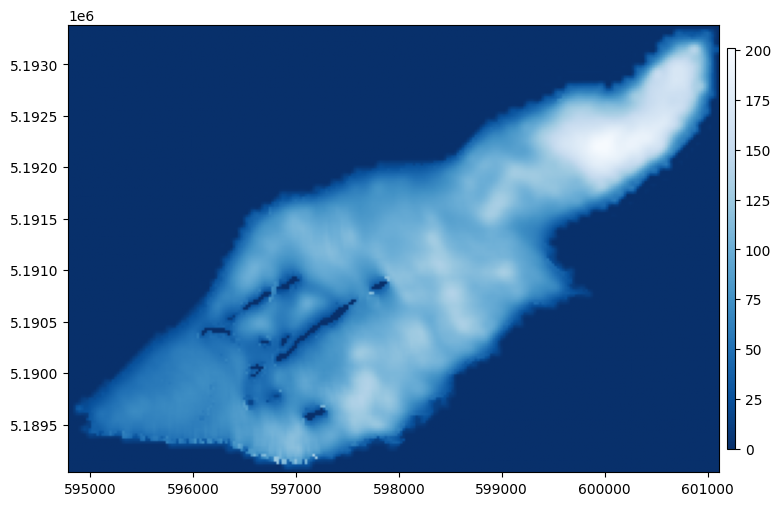

In [10]:
fig, axes = subplots(m_σ, h_transform, h_window)

## Bed Data

In [11]:
bed_file = rasterio.open(dave_bed, 'r')

transform = bed_file.transform
window = rasterio.windows.from_bounds(
    left=xmin, bottom=ymin, right=xmax, top=ymax, transform=transform
).round_lengths().round_offsets()

b_obs = bed_file.read(indexes=1, window=window, masked = True)
b_obs[b_obs < 0] = 0

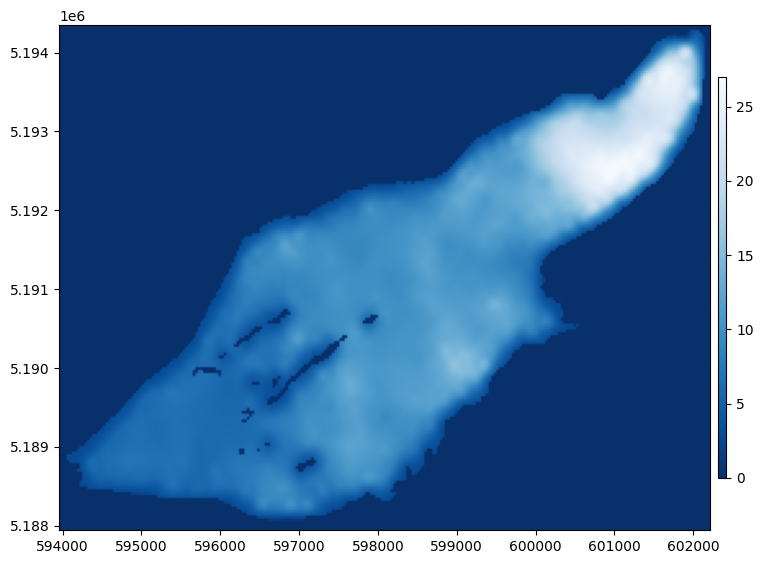

In [37]:
# Bed error is estimated to be 16% of ice thickness (?)
b_σ = 0.16 * m2_obs

fig, axes = subplots(b_σ, transform, window)

## Generate Mesh

In [13]:
gmsh_mesh = icepack.meshing.collection_to_gmsh(outline)
gmsh_mesh.write("emmons.msh", verbose=False)

mesh = firedrake.Mesh("emmons.msh") # Initial mesh

In [14]:
from firedrake.mg.mesh import MeshHierarchy

mesh0 = firedrake.Mesh('emmons.msh')
hierarchy = MeshHierarchy(mesh0, 3, 1) 
mesh = hierarchy[0] 

In [15]:
dg1 = firedrake.FiniteElement("DG", "triangle", 1)

Q = firedrake.FunctionSpace(mesh, dg1) 

In [16]:
xs = np.array(
    [
        h_transform * (i, j)
        for i in range(h_window.width) # 'window' only works for bed, for h use 'h_window'
        for j in range(h_window.height)
    ]
)

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


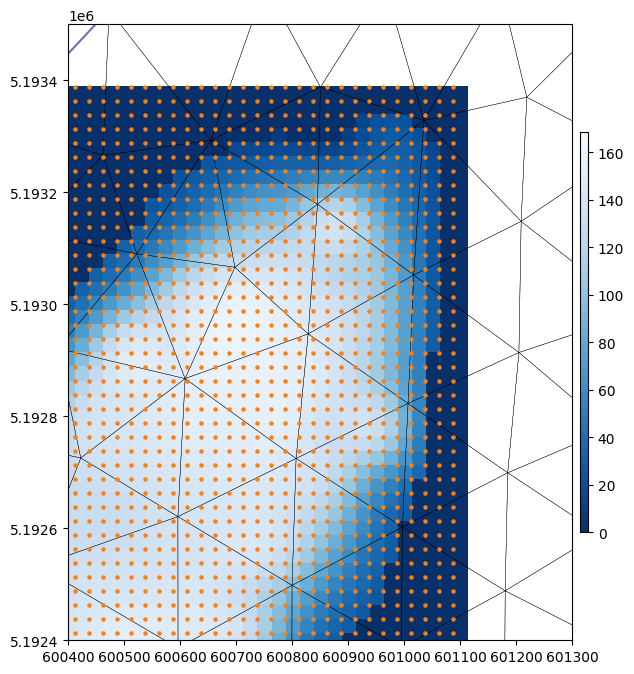

In [17]:
fig, axes = subplots(m2_obs, h_transform, h_window)
firedrake.triplot(mesh, axes=axes, interior_kw={"linewidth": 0.25})
axes.set_xlim((600400, 601300))
axes.set_ylim((5.1924e6, 5.1935e6))
#axes.set_xlim((601300, 602800))
#axes.set_ylim((5.19375e6, 5.19525e6))
axes.scatter(xs[:, 0], xs[:, 1], 5, "tab:orange");

In [18]:
indices = np.array(
    [
        (i, j)
        for i in range(h_window.width)
        for j in range(h_window.height)
        if (
            mesh.locate_cell(h_transform * (i, j)) and
            m_σ[j, i] > 0.0
        )
    ]
)
xs = np.array([h_transform * idx for idx in indices])

In [19]:
point_set = firedrake.VertexOnlyMesh(
    mesh, xs, 
    missing_points_behaviour="error"
)

In [20]:
Δ_input = firedrake.FunctionSpace(point_set.input_ordering, "DG", 0)
Δ = firedrake.FunctionSpace(point_set, "DG", 0)

def gridded_to_point_set(raster):
    f_input = firedrake.Function(Δ_input)
    f_input.dat.data[:] = raster[indices[:, 1], indices[:, 0]]
    f_output = firedrake.Function(Δ)
    f_output.interpolate(f_input)
    return f_output

h_o = gridded_to_point_set(m2_obs)
h_σ = gridded_to_point_set(m_σ)

In [21]:
m2 = fix_obs(m2_obs, m2_file)

h_initial = icepack.interpolate(m2, Δ)

In [22]:
δh = h_initial - h_o

square_error = (δh / h_σ)**2

N = len(indices)
initial_misfit = assemble(0.5 * square_error * dx) / N
print(initial_misfit)

106.76449277589008


In [23]:
def simulation(q):
    return icepack.interpolate(q, Δ)

In [24]:
area = Constant(assemble(Constant(1.0) * dx(mesh)))

In [25]:
def loss_functional(h):
    δh = abs(h_initial - h_o)
    return (1/(2 * N)) * (δh / h_σ)**2 * dx

def smoove(q_obs):
    λ = 1e6
    q = q_obs.copy(deepcopy=True)
    return 0.5 * ((q - q_obs)**2 + Constant(λ)**2 * inner(grad(q), grad(q))) * dx

In [26]:
from icepack.statistics import StatisticsProblem, MaximumProbabilityEstimator


problem = StatisticsProblem(
    simulation=simulation,
    loss_functional=loss_functional,
    regularization=smoove,
    controls = h_initial,
)

In [27]:
estimator = MaximumProbabilityEstimator(
    problem,
    gradient_tolerance=1e-4,
    step_tolerance=1e-1,
    max_iterations=50,
)
h_initial = estimator.solve()

In [34]:
h_fin = icepack.interpolate(h_initial, Q)

NotImplementedError: VertexOnlyMeshes don't have a working locate_cells_ref_coords_and_dists method

ValueError: Unsupported cell type vertex

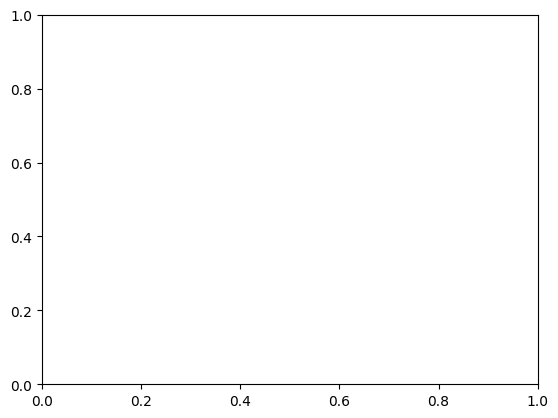

In [39]:
fig, axes = plt.subplots()
colors = firedrake.tripcolor(h_initial, axes=axes)
fig.colorbar(colors);

### Next
- comments